# Modeling Delivery Times with Neural Networks

<a href="https://colab.research.google.com/github/HassanAlgoz/dl/blob/main/modules/deep-learning/03-lab_nn/lab_nn.ipynb" target="_blank">
  <img src="https://raw.githubusercontent.com/HassanAlgoz/dl/main/assets/Open%20in%20Colab-F9AB00.svg" alt="Open in Colab" height="50"/>
</a>

Train a neural network to predict delivery time from distance.

You'll start with a **simple linear network** that works on bike-only data. Then you'll see why that same model fails when the relationship **curves** — and how a **non-linear activation** (ReLU) lets the network fit the curve.


In [1]:
# --- Setup: Clone repo & cd into correct folder (Colab only) ---
import os
import sys
import subprocess

if "google.colab" in sys.modules:
    repo_url = "https://github.com/HassanAlgoz/dl.git"
    lab_folder = "dl/modules/deep-learning/03-lab_nn"

    # Only clone if the folder doesn't exist
    if not os.path.exists(lab_folder):
        subprocess.run(["git", "clone", repo_url])

    # Change working directory to the lab folder
    os.chdir(lab_folder)

## Imports

- **`pandas`**: load CSV data into a DataFrame
- **`Pipeline`**: chain preprocessing and the model so they stay in sync
- **`StandardScaler`**: standardize features (mean 0, variance 1)
- **`MLPRegressor`**: a neural network for predicting a continuous value

This lab predicts minutes, so you'll use [`MLPRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html). For classification, scikit-learn has [`MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).


In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

import helper_utils

## The Delivery Problem

**Question:** Can a 7-mile delivery finish in under 30 minutes?

You'll train a tiny network on a handful of **bike** deliveries (distance → time), then decide whether to take a 7-mile job.


## Linear Bike Data

Load `bike_deliveries.csv`.

* `X_bike`: a DataFrame with one column, `distance_miles` (2D — what scikit-learn expects for features)
* `y_bike`: delivery times in minutes (1D — what `MLPRegressor` expects for a single output)


In [2]:
bike_df = pd.read_csv("bike_deliveries.csv")

X_bike = bike_df[["distance_miles"]]
y_bike = bike_df["delivery_time_minutes"]

bike_df

,distance_miles,delivery_time_minutes
0,1.0,6.96
1,2.0,12.11
2,3.0,16.77
3,4.0,22.21


These four points follow a **straight line**: each extra mile adds about the same amount of time.

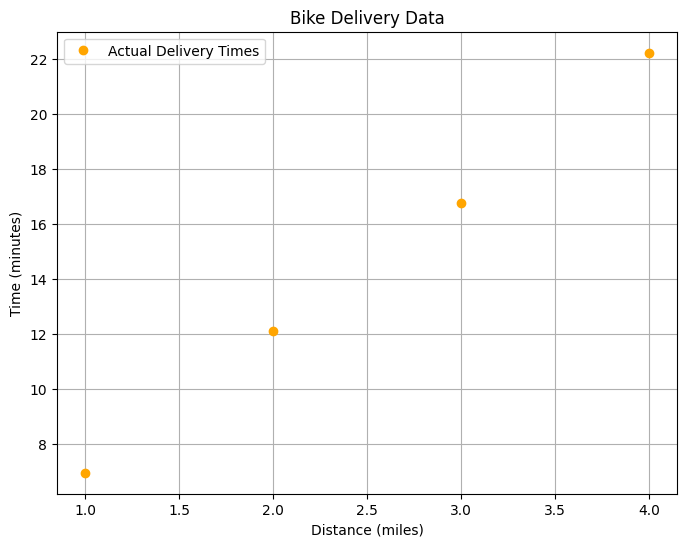

In [3]:
helper_utils.plot_data(X_bike, y_bike, title="Bike Delivery Data")

## A Simple Linear Neural Network

A single linear neuron predicts `time ≈ weight × distance + bias`.

We're skipping feature scaling for now. With one feature and a handful of miles, you can read the learned weight as "minutes per mile" and the bias as fixed overhead (pickup, start).


In [4]:
linear_model = MLPRegressor(
    hidden_layer_sizes=(),   # no hidden layer — input straight to output
    activation="identity",   # no extra non-linearity (straight line)
    solver="lbfgs",          # a good default on tiny datasets
    max_iter=1000,
    random_state=42,         # reproducible weight initialization
)

## Training

Training is a single call: `linear_model.fit(X_bike, y_bike)`.

`MLPRegressor` minimizes **squared error** — how far predicted times are from actual times — and updates the weight and bias. You don't write a training loop yourself.


In [5]:
linear_model.fit(X_bike, y_bike)

print("Training complete.")

Training complete.


### Visualize

Plot the data against the learned line:


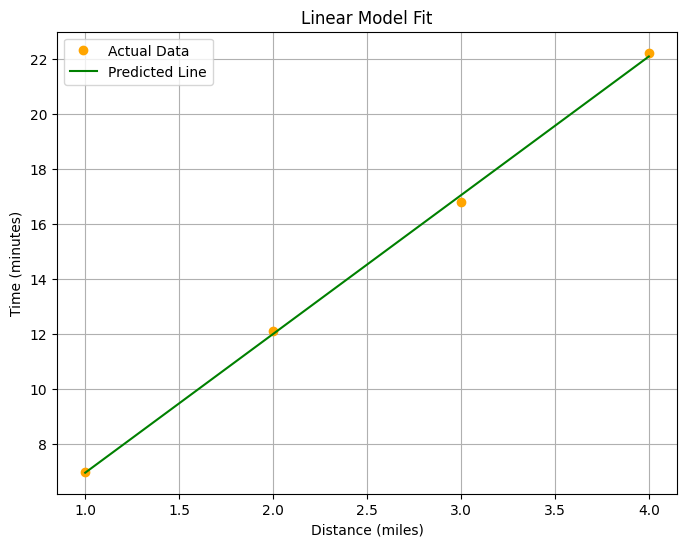

In [6]:
helper_utils.plot_fit(
    linear_model,
    X_bike,
    y_bike,
    title="Linear Model Fit",
    pred_label="Predicted Line",
)

### Predict

Predict time for a new distance, starting with `7.0` miles.

Pass a one-row DataFrame with the same column name used in training (`distance_miles`). `predict` returns an array; take the first element.


In [7]:
distance_to_predict = 7.0

In [8]:
new_distance = pd.DataFrame({"distance_miles": [distance_to_predict]})
predicted_time = linear_model.predict(new_distance)[0]

print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time:.1f} minutes")

if predicted_time > 30:
    print("\nDecision: Do NOT take the job. You will likely be late.")
else:
    print("\nDecision: Take the job. You can make it!")

Prediction for a 7.0-mile delivery: 37.2 minutes

Decision: Do NOT take the job. You will likely be late.


A 7-mile delivery is predicted over 30 minutes — decline the job.


## Inspect Parameters

With no hidden layer, `coefs_[0]` is the input-to-output weight and `intercepts_[0]` is the bias.


In [9]:
weight = linear_model.coefs_[0].item()
bias = linear_model.intercepts_[0].item()

print(f"Weight: {weight:.2f}")
print(f"Bias: {bias:.2f}")

Weight: 5.04
Bias: 1.91


**Interpretation**

- **Weight (~5.0):** minutes added per mile
- **Bias (~2.0):** fixed overhead (pickup, start)

`Time ≈ 5.0 × Distance + 2.0`


## Harder Data

Deliveries over 3 miles now go by **car**. Does the linear model still fit mixed bike and car trips?

Load `delivery_data.csv`.


In [10]:
df = pd.read_csv("delivery_data.csv")

X = df[["distance_miles"]]
y = df["delivery_time_minutes"]

df.head()

,distance_miles,delivery_time_minutes
0,1.0,6.96
1,1.5,9.67
2,2.0,12.11
3,2.5,14.56
4,3.0,16.77


This data follows a **curve**, not a straight line:

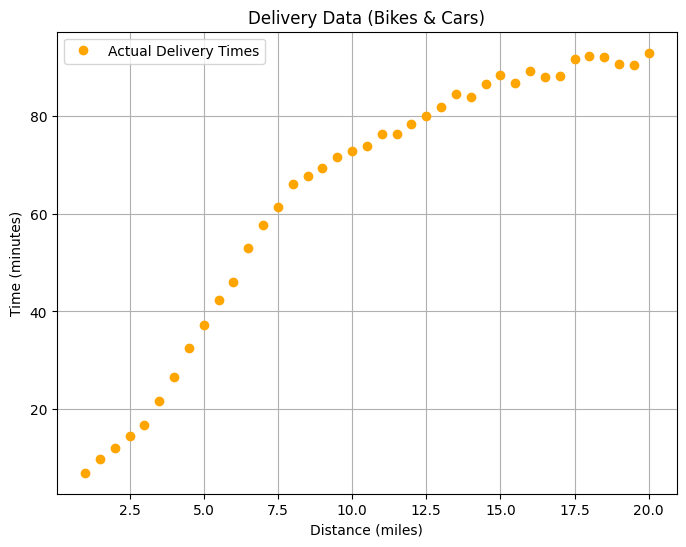

In [11]:
helper_utils.plot_data(X, y, title="Delivery Data (Bikes & Cars)")

Predict on the combined data with the **already-trained linear model** — don't retrain yet. Then plot the mismatch.


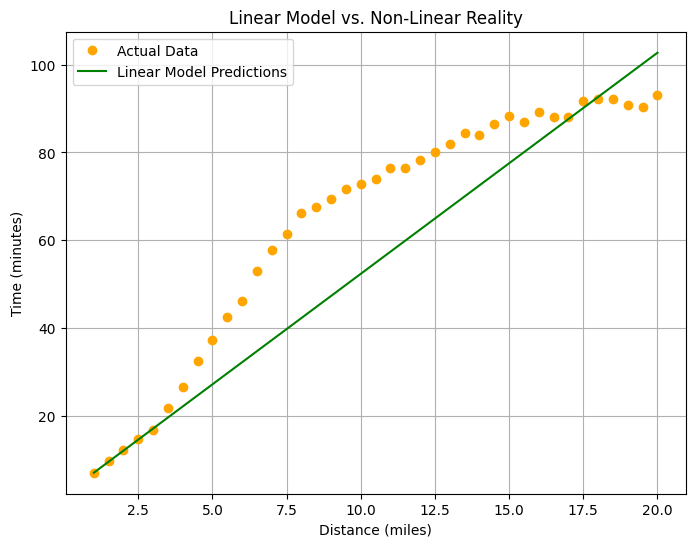

In [24]:
helper_utils.plot_fit(
    linear_model,
    X,
    y,
    title="Linear Model vs. Non-Linear Reality",
    pred_label="Linear Model Predictions",
)

**Why it fails:** the first miles beyond bike range hit city traffic; further out, cars reach highways. A straight line treats every mile the same, so it cannot fit both regimes.


## Why Adding More Neurons Isn't Enough

You might think: "If one neuron learns one relationship, more neurons should capture more complexity."

Not quite. **Stacking linear neurons still produces a straight line.**


![](../assets/two_neurons_still_linear.png){height=350}


With one neuron, that neuron *is* the output. Add a second neuron and you now have two outputs from one input — so you add another neuron to combine them. Those first two become a **hidden layer**.

Each hidden neuron still computes a weighted sum. If every step is linear (multiply by weights, add biases), the whole network collapses to one linear equation: $y = Wx + b$. Extra neurons don't help.

> Try it yourself: [TensorFlow Playground](https://playground.tensorflow.org/#activation=linear&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.21856&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) with **Activation = `linear`** (no activation function).

## The Solution: Activation Functions

To learn curves, a neuron still starts with a linear transform — but then passes the result through a **non-linear activation**. That extra step is what lets the network fit richer patterns.


![](../assets/activation_after_neuron.png){height=350}


## Introducing ReLU

We'll use **ReLU (Rectified Linear Unit)** — simple and widely used:

- **Negative input → output 0**
- **Positive input → pass through unchanged**


In [25]:
def my_relu(input: float):
    if input > 0:
        return input
    else:
        return 0

assert my_relu(-2.4) == 0
assert my_relu(3.6) == 3.6

![](../../assets/relu.png)


That's the whole function. In scikit-learn, `activation='relu'` applies it to every hidden neuron.

## How ReLU Creates Curves

A neuron still computes `W × Distance + B`. Without ReLU, that's a straight line. With ReLU:

- When `W × Distance + B` is **negative**, the output is **0** (a flat segment)
- When it's **positive**, the output follows the line

That's a **bend** — a corner where behavior changes. It sits where `W × Distance + B = 0`, i.e. at `Distance = -B/W`.


## Multiple Neurons, Multiple Bends

The delivery curve doesn't bend just once — traffic changes across distances. **One neuron gives one bend; several neurons give several bends.**

Each neuron has its own weight and bias, so each activates at a different distance:

- Neuron 1 around 3 miles (city traffic starts)
- Neuron 2 around 8 miles (entering highways)
- Neuron 3 around 15 miles (full highway speeds)

Add their outputs together and you approximate the curve. With enough neurons, you can approximate any smooth curve.


![](../assets/five_relu_activated_neurons.png)


## Building a Non-Linear Model

Next you'll:

* Put a `StandardScaler` in a **pipeline** so scaling happens automatically at train and predict time
* Build an `MLPRegressor` with **ReLU** and **3 hidden neurons**
* Train on the combined bike and car data, and see if it succeeds where the linear model failed


### Scaling Features in a Pipeline

Neural networks are sensitive to input scale. Distances here range from 1 to 20 miles, so scikit-learn recommends scaling before training an MLP.

**Standardization** (z-score) recenters each feature to mean 0 and standard deviation 1. The curved pattern stays the same — only the axis scale changes.

You *could* scale by hand with `(value - mean) / std`. The trap is at prediction time: you must reuse the **training** mean and std, not compute new ones from the new input.

A **pipeline** handles that. Put `StandardScaler` in front of `MLPRegressor`. On `fit`, the scaler learns from the training distances, then the MLP trains on scaled values. On `predict`, the same fitted scaler is applied automatically.


### Understanding the Architecture

The input is your data; `MLPRegressor` adds the output layer. You mainly choose the hidden layer and the activation.

Each hidden neuron computes `W × Distance + B` with its own weight and bias, so each can bend at a different distance. ReLU is the non-linear step that creates those bends. The output neuron combines the hidden outputs into a predicted time (identity activation, squared-error loss — same idea as the linear model).

Want a smoother curve? Increase the number of hidden neurons.


![](../../assets/three_relu_activated_neurons.png)


In [ ]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(3,),  # one hidden layer, 3 neurons; (8, 4) would be two layers
        activation="relu",        # non-linear step that creates the bends
        solver="lbfgs",           # reliable on a few dozen rows (better than Adam/SGD here)
        max_iter=3000,            # L-BFGS cap; usually stops earlier once loss flattens
        random_state=287,         # reproducible weight initialization
    )),
])

## Training the Non-Linear Model

`model.fit(X, y)` fits the scaler, transforms the distances, then trains the MLP.


In [42]:
model.fit(X, y)

print("Training complete.")

Training complete.


## Checking the Final Fit

Plot the predicted curve against the data. Dashed lines mark where each of the three hidden neurons bends.


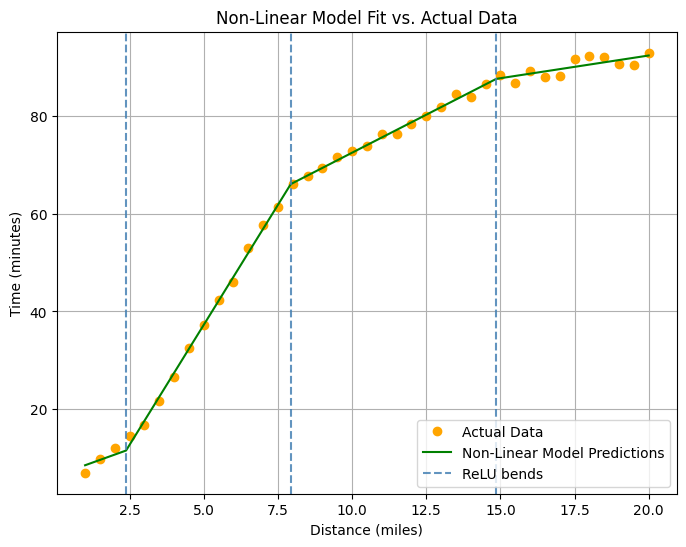

In [43]:
helper_utils.plot_fit(
    model,
    X,
    y,
    title="Non-Linear Model Fit vs. Actual Data",
    pred_label="Non-Linear Model Predictions",
    mark_bends=True,
)

The linear model couldn't follow bike+car data. The ReLU network can.


## Making a Prediction

The scaler lives **inside** the pipeline, so you pass the distance in **miles**. The pipeline applies the same standardization it learned during `fit`.

The company now promises **45 minutes** (mixed bike/car trips take longer than the 30-minute bike-only jobs) and wants to know which vehicle to use.


In [39]:
distance_to_predict = 5.1

In [40]:
new_distance = pd.DataFrame({"distance_miles": [distance_to_predict]})
predicted_time = model.predict(new_distance)[0]

print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time:.1f} minutes")

if predicted_time > 45:
    print("\nDecision: Do NOT promise the delivery in under 45 minutes.")
else:
    if distance_to_predict <= 3:
        print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (<= 3 miles), use a bike.")
    else:
        print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (> 3 miles), use a car.")

Prediction for a 5.1-mile delivery: 38.2 minutes

Decision: Yes, delivery is possible. Since the distance is 5.1 miles (> 3 miles), use a car.


## Conclusion

A one-neuron linear network fit the bike data and made a 7-mile decision. The same model failed once cars were added — a straight line cannot follow a curve.

**ReLU** plus a few hidden neurons fixed that. A `StandardScaler` in a **pipeline** keeps feature scaling attached to the model at train and predict time.
